In [2]:
# %% Import the libraries we need
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("dataset/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

# Optional: inspect the first rows
dataset.head()


,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,solar_rel_prod,wind_rel_prod,latitude,longitude,country,solar_layout_MW,wind_layout_MW
0,2012-01-01 00:00:00+00:00,1,75.6549,9.150821,0.0,18.301642,0.0,0.0284,42.094674,-8.113982,POR,982.8607,644.4240
1,2012-01-01 00:00:00+00:00,2,557.8868,6.196411,0.0,12.392822,0.0,0.0103,41.587435,-8.326462,POR,1361.0601,1203.1866
2,2012-01-01 00:00:00+00:00,3,15.5237,6.855084,0.0,13.710167,0.0,0.0283,41.585994,-6.722728,POR,746.4879,484.4582
3,2012-01-01 00:00:00+00:00,4,8.6425,7.824092,0.0,15.648183,0.0,0.0408,41.597684,-6.342848,POR,456.1251,383.5339
4,2012-01-01 00:00:00+00:00,5,85.3649,2.053690,0.0,4.107380,0.0,0.0092,41.373957,-7.350949,POR,986.4986,446.4544


In [3]:
def maxima_values(series):
    peak_indices, _ = find_peaks(series)
    return series[peak_indices]


0            75.6549
1494         70.9958
2988         66.6382
4482         62.9920
5976         61.0699
              ...   
39290706    102.7619
39292200     99.4563
39293694     92.7608
39295188     85.9727
39296682     82.3471
Name: demand_MWh, Length: 26304, dtype: float64

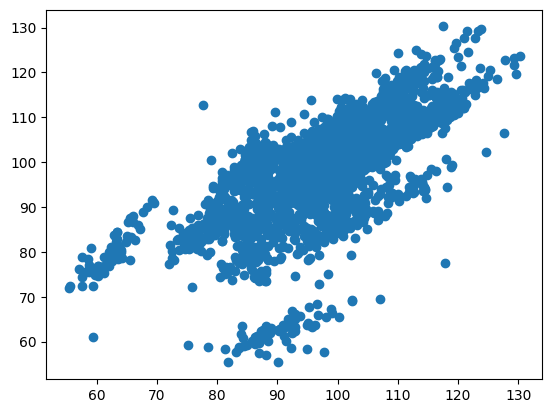

In [17]:
M_true = maxima_values(dataset[(dataset["ID"]=="1")]["demand_MWh"].to_numpy())
plt.scatter(M_true[:-1], M_true[1:])

In [9]:
M_true

Series([], Name: demand_MWh, dtype: float64)